
# Who won what — nation × sport × medal, *fully attributable*
### The capstone **gradient‑sankey** project — built *com todo cuidado e carinho* 💙

Welcome to the graduation project! 👋 If `08_tutorial_olympics.ipynb` taught the **ranking race of
nations** (country → medal), this lesson goes one layer deeper and answers a harder question:
**which country won which medals, *in which sport*?** — across **120 years** of the Summer Games.

That sounds like it should just be a **3‑column Sankey** (`country → sport → medal`). But it *isn't*,
and understanding **why not** is the whole lesson. We'll hit a fundamental limit of Sankey diagrams,
then fix it with two ideas:

1. **Un‑pooling** the middle layer so each sport node belongs to **one** nation, and
2. **Synchronized ranking** — a brand‑new `gradient‑sankey` capability that makes a nation and *its*
   sport nodes **race together as one block**.

> 🏅 The payoff: a reel where nations **re‑rank every Games** (USA vs the USSR for #1), each nation's
> **signature sports ride along beneath it**, and you can trace a ribbon from **USA → USA · Athletics →
> Gold** without it ever getting mixed up with anyone else's.

---

### What we'll build

A **3‑layer Sankey**: **nations** (left) → **nation‑specific sport nodes** like `USA · Athletics`
(middle, coloured by nation) → **Gold / Silver / Bronze** (right). Bar width = **medals**. Nations
**race** by medal count each Games, and a nation's sport nodes stay **grouped under it**. A footer
chart tracks the leaders' combined medals.

### Learning outcomes

1. **Extract** the data and apply the load‑bearing **team‑sport de‑dup** — this time **keeping the
   `Sport`** — plus **stitching** dissolved NOCs (USSR→Russia, E+W Germany).
2. **Explore**: each nation's **signature sports**, and the **per‑window leadership** table that the
   racing view will dramatize.
3. Understand **the Sankey pooling theorem**: in `A → B → C`, node `B` merges its inflows, so the
   `A → C` join is *lost*. See it fail, then fix it by **un‑pooling** `B`.
4. Build a **balanced** `country → nation·sport → medal` flow table over a **rolling window**.
5. Drive every relevant **module/mode**: `stacked_mode`, `ranking_mode`, **`set_group_parents`
   (synchronized ranking)**, `dynamic_color_mode` **vs** fixed per‑nation colours + `fixed_color_nodes`,
   the **value axis**, the **overlay**, and **`annotations`/`hold_periods`** beat captions.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it imports
> only `gradient_sankey` (the committed module at the repo root), the Python standard library, and the
> pip package `pandas`. The public CSV download, the de‑dup, the NOC stitch and the whole un‑pooled
> flow‑builder are **inlined below as teaching steps**, so you can read the full pipeline end to end. 💙



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We add
the repo root to `sys.path` so we always get the **local** copy with the newest features.

```bash
pip install gradient-sankey        # the public package
# this notebook uses the LOCAL repo copy via sys.path (see below)
```

> ⚠️ **Heads‑up — local‑only features (the new stuff this lesson is *about*).** This reel needs
> capabilities that live in this **local** `gradient_sankey.py` and may be newer than your pinned pip
> release — check your installed `gradient-sankey` if a knob is missing:
> - **`set_group_parents(child_parent, demote)`** — *synchronized ranking*: order one layer to follow
>   another's ranking, keeping each parent's children grouped (the heart of this lesson),
> - **`fixed_color_nodes`** — keep chosen nodes (the metallic medals) un‑recoloured under dynamic modes,
> - the **value axis** (`yaxis_node`, `yaxis_gap`, `layer0_label_side`, `value_prefix=""`),
> - the **overlay** controls (`overlay_band`, `overlay_badge`, `overlay_x_labels`), and
> - **`annotations` / `hold_periods`** — on‑screen beat captions + brief pauses.
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We need `pandas` for the data (plus the standard library to fetch the CSV) and the library for the
visuals. An **MP4** also needs **FFmpeg** on your PATH — but `save_frame` stills need nothing, and
(unlike the rank‑colour tutorials) **our stills are fully faithful** because we colour by *nation*,
not by per‑frame rank.


In [1]:
import os, sys, pathlib, urllib.request

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import pandas as pd
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the one CSV download, so a re-run is instant.
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=1000):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("has set_group_parents:", hasattr(Sankey, "set_group_parents"))   # the new feature


gradient-sankey version: 1.2.2
pandas: 3.0.1
has set_group_parents: True



## 2 · The data — *one row per athlete*, two gotchas to fix

We use the classic **["120 years of Olympic history"](https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results)**
dataset (`athlete_events.csv`) — every modern Games **Athens 1896 → Rio 2016**, one CSV, no key:

```
https://raw.githubusercontent.com/Thomas-George-T/Olympic-History-Analytics-in-R/main/athlete_events.csv
```

271,116 rows × 15 columns. The ones we need: `Year`, `Season`, `Games`, `NOC` (country code),
**`Sport`** (the discipline — *new for this lesson*), `Event`, and `Medal` (`Gold`/`Silver`/`Bronze`
or `NaN`).

> ### ⚠️ Gotcha #1 — *one row per athlete per event* (the over‑count trap)
> A **basketball** gold is **12 rows**, a **relay** gold **4+**, **hockey** **~16**. Counting rows
> makes team sports explode. Fix: **`drop_duplicates(["Games","Event","Medal","NOC"])`** → one
> *physical* medal per event‑placing. (`NOC` stays in the key so a rare two‑bronze event still counts
> both nations.)
>
> ### ⚠️ Gotcha #2 — *nations that dissolved* (NOC stitching)
> The **USSR** (`URS`) becomes the **Unified Team** (`EUN`, 1992) then **Russia** (`RUS`); **East**
> (`GDR`) + **West** (`FRG`) Germany merge into **`GER`**. To tell a continuous story we **stitch**
> these into single entities (`URS/RUS`, `GER`) with a small replace‑map — exactly
> `olympics_reel.NOC_MERGE`.



## 3 · Load, de‑duplicate **keeping the Sport**, stitch NOCs — and verify

One download (~40 MB), cached to our local `.nbcache/`. We de‑dup to one medal per
`(Games, Event, Medal, NOC)` **but keep the `Sport` column** this time, stitch the dissolved NOCs,
then **verify** against a known fact (USA all‑time Summer golds ≈ 1,000).


In [2]:
OLYMPICS_URL = ("https://raw.githubusercontent.com/Thomas-George-T/"
                "Olympic-History-Analytics-in-R/main/athlete_events.csv")

def load_olympics():
    cf = CACHE / "athlete_events.csv"
    if not cf.exists():
        print("downloading athlete_events.csv (~40 MB) ...")
        urllib.request.urlretrieve(OLYMPICS_URL, cf)
    return pd.read_csv(cf)

# dissolved-state stitching (olympics_reel.NOC_MERGE)
NOC_MERGE = {"URS": "URS/RUS", "EUN": "URS/RUS", "RUS": "URS/RUS",   # Soviet Union -> Russia
             "GDR": "GER", "FRG": "GER",                            # East + West -> Germany
             "TCH": "CZE", "CZE": "CZE"}                            # Czechoslovakia -> Czechia
SEASON = "Summer"

raw = load_olympics()
m = raw[(raw.Season == SEASON) & raw.Medal.notna()].copy()
print(f"{SEASON} medal ROWS (athlete-event, pre-dedup): {len(m):,}")

# THE de-dup (keep Sport!): one physical medal per (Games, Event, Medal, NOC)
m = m.drop_duplicates(subset=["Games", "Event", "Medal", "NOC"])
print(f"{SEASON} medals after de-dup:                   {len(m):,}")

# tidy table WITH the sport, then stitch dissolved NOCs
tab = m.groupby(["Year", "NOC", "Sport", "Medal"]).size().rename("n").reset_index()
tab["NOC"] = tab["NOC"].replace(NOC_MERGE)
tab = tab.groupby(["Year", "NOC", "Sport", "Medal"], as_index=False)["n"].sum()

# VERIFY: USA all-time Summer golds ~1000, total ~2500
usa = tab[tab.NOC == "USA"]
usa_gold, usa_total = int(usa[usa.Medal=="Gold"]["n"].sum()), int(usa["n"].sum())
print(f"\nSANITY CHECK — USA all-time {SEASON}: golds={usa_gold}, total={usa_total} "
      f"(known ~1000 / ~2500 -> de-dup correct ✅)")
assert 950 <= usa_gold <= 1100 and 2400 <= usa_total <= 2700
tab.head(6)


downloading athlete_events.csv (~40 MB) ...


Summer medal ROWS (athlete-event, pre-dedup): 34,088
Summer medals after de-dup:                   16,052



SANITY CHECK — USA all-time Summer: golds=1035, total=2544 (known ~1000 / ~2500 -> de-dup correct ✅)


,Year,NOC,Sport,Medal,n
0,1896,AUS,Athletics,Gold,2
1,1896,AUS,Tennis,Bronze,1
2,1896,AUT,Cycling,Bronze,2
3,1896,AUT,Cycling,Gold,1
4,1896,AUT,Swimming,Gold,1
5,1896,AUT,Swimming,Silver,1



## 4 · Exploratory analysis — signature sports & who led each Games 🔎

Two quick explorations that *are* the story:

**(a) Each nation's signature sports.** The USA lives on **Athletics + Swimming**; **France/Italy** on
**Fencing**; the **USSR** on **Gymnastics**. These all‑time top sports become our named middle nodes.

**(b) Who actually led each Games.** Using a **rolling 2‑Games window** (≈ current form), we find the
window leader. This reveals the duel the reel will dramatize: the **USA** leads most years, but the
**USSR** seizes #1 in **1956–64, 1980, 1984, 1992** — the Cold‑War peaks (and the boycotts).


In [3]:
TOP_N = 6
top_nocs = tab.groupby("NOC")["n"].sum().sort_values(ascending=False).head(TOP_N).index.tolist()
print("Top", TOP_N, "nations (all-time):", top_nocs, "\n")

# (a) signature sports per nation (all-time top 3)
print("Signature sports (all-time medals):")
for noc in top_nocs:
    s = tab[tab.NOC == noc].groupby("Sport")["n"].sum().sort_values(ascending=False).head(3)
    print(f"  {noc:8s}", ", ".join(f"{sp} {int(v)}" for sp, v in s.items()))


Top 6 nations (all-time): ['USA', 'URS/RUS', 'GER', 'GBR', 'FRA', 'ITA'] 

Signature sports (all-time medals):
  USA      Athletics 816, Swimming 550, Diving 135
  URS/RUS  Athletics 291, Gymnastics 241, Wrestling 192
  GER      Athletics 264, Swimming 188, Canoeing 122
  GBR      Athletics 212, Cycling 93, Swimming 79
  FRA      Fencing 123, Cycling 98, Athletics 70
  ITA      Fencing 127, Cycling 63, Athletics 60


In [4]:
# (b) per-window leadership (rolling 2-Games totals among the tracked nations)
sub = tab[tab.NOC.isin(top_nocs)]
years = sorted(sub.Year.unique())
wide = (sub.groupby(["Year", "NOC"])["n"].sum().unstack(fill_value=0)
        .reindex(columns=top_nocs).reindex(years, fill_value=0))
roll = wide.rolling(2, min_periods=1).sum()       # ~8-yr 'current form'
lead = roll.idxmax(axis=1)
print("Window leader by Games (rolling 2):")
shown = None
for y in years:
    if lead[y] != shown:                          # print only when the lead CHANGES
        shown = lead[y]
        print(f"  {y}: {lead[y]:8s} ({int(roll.loc[y, lead[y]])} medals, window)")


Window leader by Games (rolling 2):
  1896: USA      (19 medals, window)
  1900: FRA      (113 medals, window)
  1904: USA      (284 medals, window)
  1908: GBR      (168 medals, window)
  1920: USA      (158 medals, window)
  1956: URS/RUS  (168 medals, window)
  1968: USA      (197 medals, window)
  1976: GER      (235 medals, window)
  1980: URS/RUS  (320 medals, window)
  1988: USA      (267 medals, window)
  1992: URS/RUS  (243 medals, window)
  1996: USA      (209 medals, window)



## 5 · Why a naïve `country → sport → medal` Sankey **fails** 🧠

The obvious design is three shared columns: nations, then sports, then medals. But here's the
**Sankey pooling theorem**:

> In any `A → B → C` Sankey, an intermediate node **B pools all of its inflows**. The "Athletics" node
> merges *everyone's* athletics medals into one lump, then splits that lump into Gold/Silver/Bronze.
> **The country identity is destroyed at the sport node** — you can read `country → sport` and
> `sport → medal`, but never the *join* `country → sport → medal`.

So a shared "Athletics" node can't tell you whose gold it is. We need the middle nodes to **carry the
country**. That's **un‑pooling**: instead of one shared `Athletics`, we make **`USA · Athletics`**,
**`GBR · Athletics`**, … — each belonging to exactly one nation. Now a node's outgoing medal ribbons
are unambiguously *that nation's*, and the full triple survives. (Cost: more nodes — so we keep each
nation's **top‑k** sports and fold its tail into a per‑nation **`… · other`** so totals stay honest.)



## 6 · Build the **balanced** `country → nation·sport → medal` flows

This reproduces `attribution_flows`. For each nation we keep its all‑time **top‑`K` sports** as named
nodes and bucket the rest into `"<NOC> · other"`. We densify over a **rolling window** (so the race
moves), then emit **two halves from the same finest‑grain counts** so the diagram **balances** exactly
(a sport node's inflow from its nation == its outflow to medals):

- **half A:** `country → "<NOC> · sport"`  (value = that nation's medals in that sport, this window)
- **half B:** `"<NOC> · sport" → medal`     (value = those medals split by metal)


In [5]:
SEP, OTHER = " · ", "other"
K_SPORTS, ROLL = 2, 2
MEDALS = ["Gold", "Silver", "Bronze"]

t = tab[tab.NOC.isin(top_nocs)].copy()
# each nation's all-time top-K sports -> stable named nodes; rest -> '<NOC> · other'
keep = {noc: t[t.NOC==noc].groupby("Sport")["n"].sum().sort_values(ascending=False)
                 .head(K_SPORTS).index.tolist() for noc in top_nocs}
t["mid"] = [f"{n}{SEP}{s}" if s in keep[n] else f"{n}{SEP}{OTHER}"
            for n, s in zip(t["NOC"], t["Sport"])]

g = (t.groupby(["Year","NOC","mid","Medal"])["n"].sum().rename("value").reset_index()
       .rename(columns={"Year":"year","NOC":"country","Medal":"medal"}))

# densify over valid (country,mid) x years x medals, then ROLLING sum (the window)
pairs = g[["country","mid"]].drop_duplicates()
full = (pairs.assign(k=1).merge(pd.DataFrame({"year":years,"k":1}),on="k")
        .merge(pd.DataFrame({"medal":MEDALS,"k":1}),on="k").drop(columns="k"))
g = full.merge(g, on=["year","country","mid","medal"], how="left").fillna({"value":0.0}).sort_values("year")
g["value"] = g.groupby(["country","mid","medal"])["value"].transform(
    lambda s: s.rolling(ROLL, min_periods=1).sum())
g = g[g["value"] > 0]

# two balanced halves
cs = (g.groupby(["year","country","mid"])["value"].sum().reset_index()
        .rename(columns={"country":"source","mid":"target"}))
mm = (g.groupby(["year","mid","medal"])["value"].sum().reset_index()
        .rename(columns={"mid":"source","medal":"target"}))
df = pd.concat([cs[["year","source","target","value"]],
                mm[["year","source","target","value"]]], ignore_index=True)
print(f"{len(df)} flow rows; e.g. USA · Athletics this/most recent window:")
display(df[(df.source=="USA · Athletics")].tail(3))


1779 flow rows; e.g. USA · Athletics this/most recent window:


,year,source,target,value
1770,2016,USA · Athletics,Bronze,16.0
1771,2016,USA · Athletics,Gold,22.0
1772,2016,USA · Athletics,Silver,22.0



**Check the balance.** For every sport node, inflow (from its nation) must equal outflow (to medals).
If this assert passes, the diagram is conservative and the bars are trustworthy.


In [6]:
bad = 0
mids_set = set(g["mid"])
for y in df.year.unique():
    f = df[df.year == y]
    infl = f[f.target.isin(mids_set)].groupby("target")["value"].sum()
    outfl = f[f.source.isin(mids_set)].groupby("source")["value"].sum()
    if (infl.sub(outfl, fill_value=0).abs() > 1e-6).any():
        bad += 1
print(f"sport-node imbalance in {bad} of {df.year.nunique()} Games  (0 = perfectly balanced ✅)")


sport-node imbalance in 0 of 29 Games  (0 = perfectly balanced ✅)



## 7 · Layers & colours — one hue per nation

Three layers: **nations** → **nation·sport nodes** → **medals**. The design choice that makes this
readable: **each nation gets one distinct hue, and its sport nodes inherit it** — so a nation, its
sports, and their ribbons read as one colour family. Medals stay **metallic**. We pick **widely
spaced** hues so adjacent blocks stay distinct when they re‑rank. This is the colour block of
`attribution_flows`.


In [7]:
# 6 widely-spaced nation hues (matches olympics_attribution_reel.COUNTRY_PALETTE)
COUNTRY_PALETTE = ["#35C9E8", "#F72585", "#FFD23F", "#9B6CF0", "#2ECC71", "#FF4D4D"]
MEDAL_COLORS = {"Gold": "#FFD24A", "Silver": "#C7CDD4", "Bronze": "#CD7F4B"}

# middle order: grouped BY NATION (kept sports by all-time desc, then that nation's 'other')
present_mid = set(g["mid"])
mid_order = []
for noc in top_nocs:
    for sp in keep[noc]:
        node = f"{noc}{SEP}{sp}"
        if node in present_mid: mid_order.append(node)
    onode = f"{noc}{SEP}{OTHER}"
    if onode in present_mid: mid_order.append(onode)
medals = [m for m in MEDALS if m in set(g["medal"])]
LAYERS = [top_nocs, mid_order, medals]

node_colors = {}
for i, noc in enumerate(top_nocs):
    col = COUNTRY_PALETTE[i % len(COUNTRY_PALETTE)]
    node_colors[noc] = col
    for node in mid_order:
        if node.startswith(noc + SEP):
            node_colors[node] = col           # sport nodes inherit the nation's hue
node_colors.update(MEDAL_COLORS)

print("nations (L):", LAYERS[0])
print("middle  (M):", LAYERS[1])
print("medals  (R):", LAYERS[2])


nations (L):

 ['USA', 'URS/RUS', 'GER', 'GBR', 'FRA', 'ITA']
middle  (M): ['USA · Athletics', 'USA · Swimming', 'USA · other', 'URS/RUS · Athletics', 'URS/RUS · Gymnastics', 'URS/RUS · other', 'GER · Athletics', 'GER · Swimming', 'GER · other', 'GBR · Athletics', 'GBR · Cycling', 'GBR · other', 'FRA · Fencing', 'FRA · Cycling', 'FRA · other', 'ITA · Fencing', 'ITA · Cycling', 'ITA · other']
medals  (R): ['Gold', 'Silver', 'Bronze']



## 8 · **Synchronized ranking** — the heart of this lesson 🔗

We want two things that normally fight each other:
- **the race** — nations re‑rank by medals each Games (`ranking_mode=True`), and
- **the grouping** — each nation's sport nodes stay **together, under their nation**.

Plain `ranking_mode` ranks **every layer independently**, which would scatter the sport nodes by their
own size (re‑pooling the confusion). The fix is **`set_group_parents`**: we hand the library a map of
**each middle node → its parent nation**, plus the per‑nation `… · other` buckets to **demote** to the
end of their group. Now the middle layer is ordered to **follow the nations' ranking** — a nation and
its sports move as **one contiguous block**, and a nation with **0 medals** in a window **collapses
with no blank slot**.

> This is exactly what `attribution_reel` does. The mapping is trivial to build from our node names —
> the parent is just the text before `" · "`.


In [8]:
sk = Sankey.from_dataframe(
    df=df, layers=LAYERS,
    time_col="year", source_col="source", target_col="target", value_col="value",
    node_colors=node_colors,
)

# the new feature: link each "<NOC> · sport" node to its nation, demote the buckets
child_parent = {m: m.split(SEP)[0] for m in mid_order}
demote = {m for m in mid_order if m.endswith(SEP + OTHER)}
sk.set_group_parents(child_parent, demote)

anchor = top_nocs[0]   # the leading nation anchors the medal-count axis
print(f"{len(sk.frames)} frames (Games):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("grouped middle nodes ->", len(child_parent), "linked to", len(set(child_parent.values())), "nations")


29 frames (Games): 1896 -> 2016
grouped middle nodes -> 18 linked to 6 nations



## 9 · Every module / mode we use — and *why* 🎛️

The question every newcomer asks: *stacking? ranking? dynamic colours?* Here is the exact recipe for
**this** reel, and the reasoning:

| Knob | Value | Module / mode — why |
|---|---|---|
| `stacked_mode` | `True` | **Stacking**: bar height ∝ medal count (biggest nation = tallest). |
| `ranking_mode` | `True` | **Ranking**: reorder by value each frame — *the race*. |
| `set_group_parents(…)` | — | **Synchronized ranking**: middle nodes follow their nation's rank (keeps groups intact + collapses empty nations). |
| `dynamic_color_mode` | **`"static"`** | We deliberately **do NOT** use rank colours here — colour carries **nation identity**, so it must be fixed. (Contrast: `08_tutorial_olympics` uses `"ranking"` to colour by rank — great when colour = rank, wrong when colour = identity.) |
| `fixed_color_nodes` | the 3 medals | Belt‑and‑braces: keep Gold/Silver/Bronze **metallic** even if a dynamic mode is ever switched on. |
| `theme` / `link_glow` / `link_alpha` / `n_segments` | dark / 1 / 0.6 / 90 | The neon‑on‑black look + smooth gradient ribbons. |
| `yaxis_node` / `yaxis_suffix` / `value_prefix` | leader / `""` / `""` | A **medal‑count** value axis (not dollars). |
| `yaxis_gap` / `layer0_label_side` | 0.15 / `"left"` | Axis hugs the nation column; names on the left. |
| `margin_bottom` / `overlay_band` | 0.28 / (0.16, 0.42) | Reserve a roomy footer and push the line chart **low**, clear of the Sankey. |
| `overlay_series` / `overlay_x_labels` / `overlay_badge` | totals / years / `"TOP 6"` | The footer growth chart + corner tag. |
| `annotations` / `hold_periods` | the beats | On‑screen captions + brief pauses on 1956/1980/1984/1992. |

> **The mental model:** `stacked_mode` sizes the bars, `ranking_mode` *orders* them, and
> `set_group_parents` *links* the ordering of one layer to another. Colour is an orthogonal axis: use
> **dynamic** when colour should mean *rank*, **static** when colour should mean *identity* (as here).



## 10 · Render a short proof

Stills first — `save_frame` needs **no FFmpeg**. And because we colour by **nation** (not by per‑frame
rank), **these stills are fully faithful** — they show the real colours *and* the synchronized layout.
We render two Games that prove both fixes:

- **1936** — the USSR doesn't exist yet → its block is simply **absent, no blank slot**,
- **1980** — Moscow boycott → **URS/RUS rockets to #1**, its sports grouped right beneath it.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\attribution_1936.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\attribution_1936.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\attribution_1980.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\attribution_1980.png


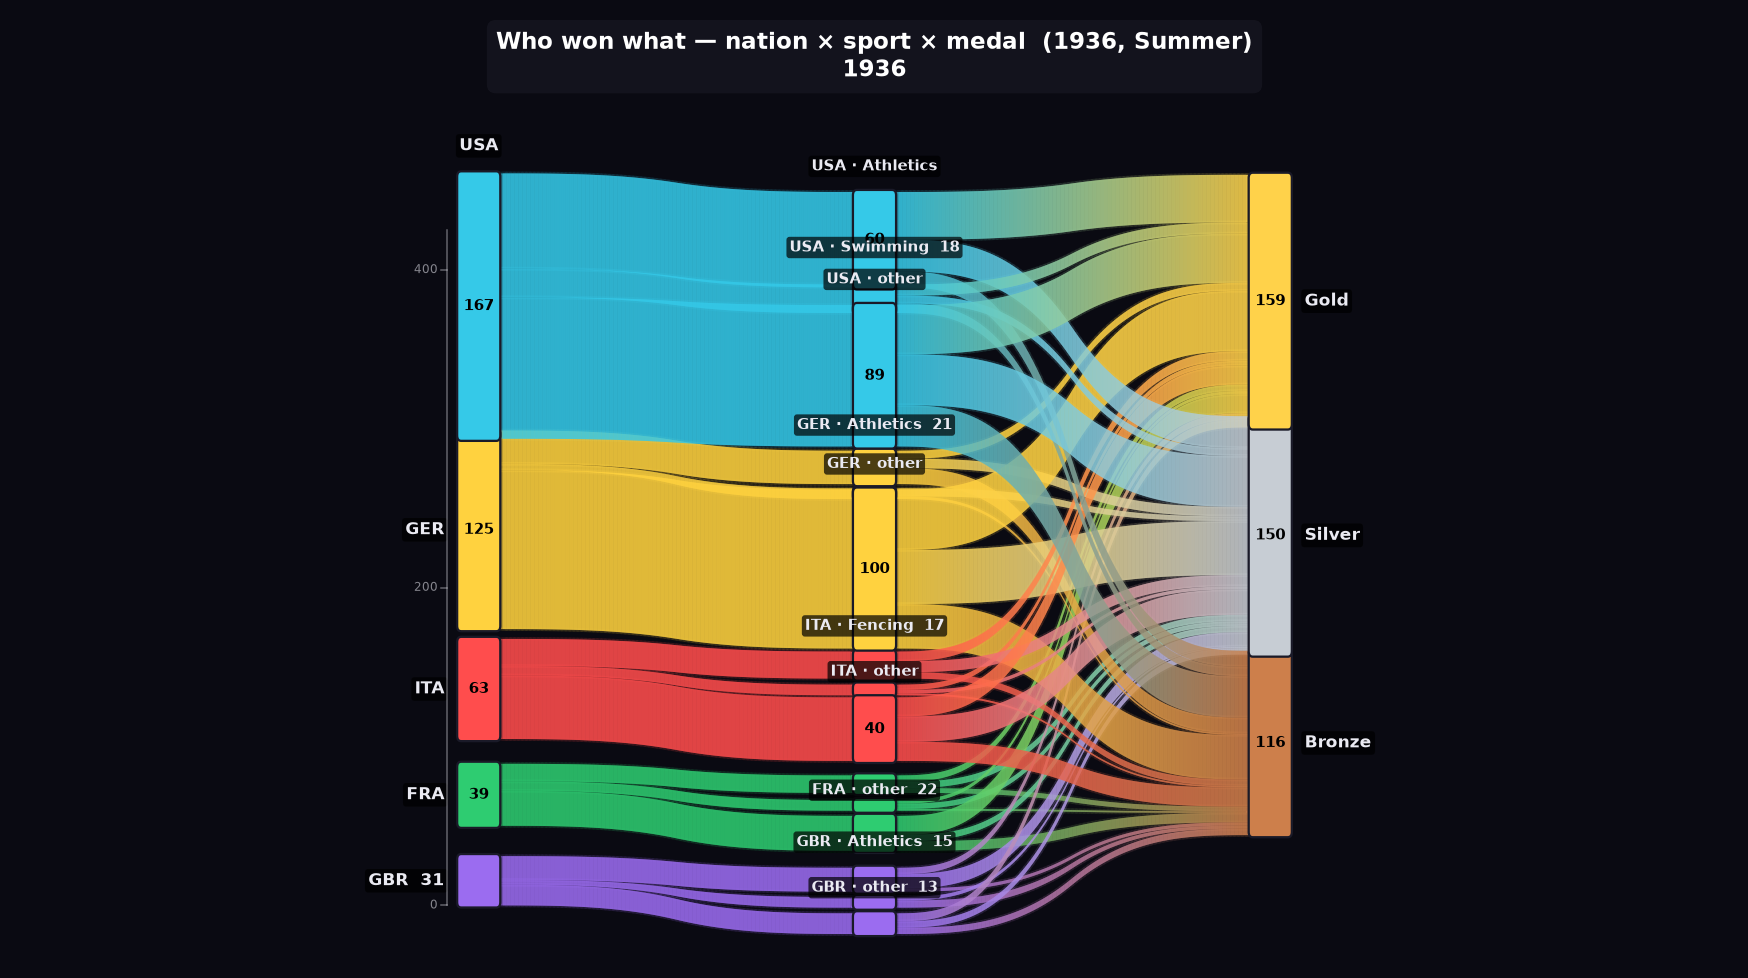

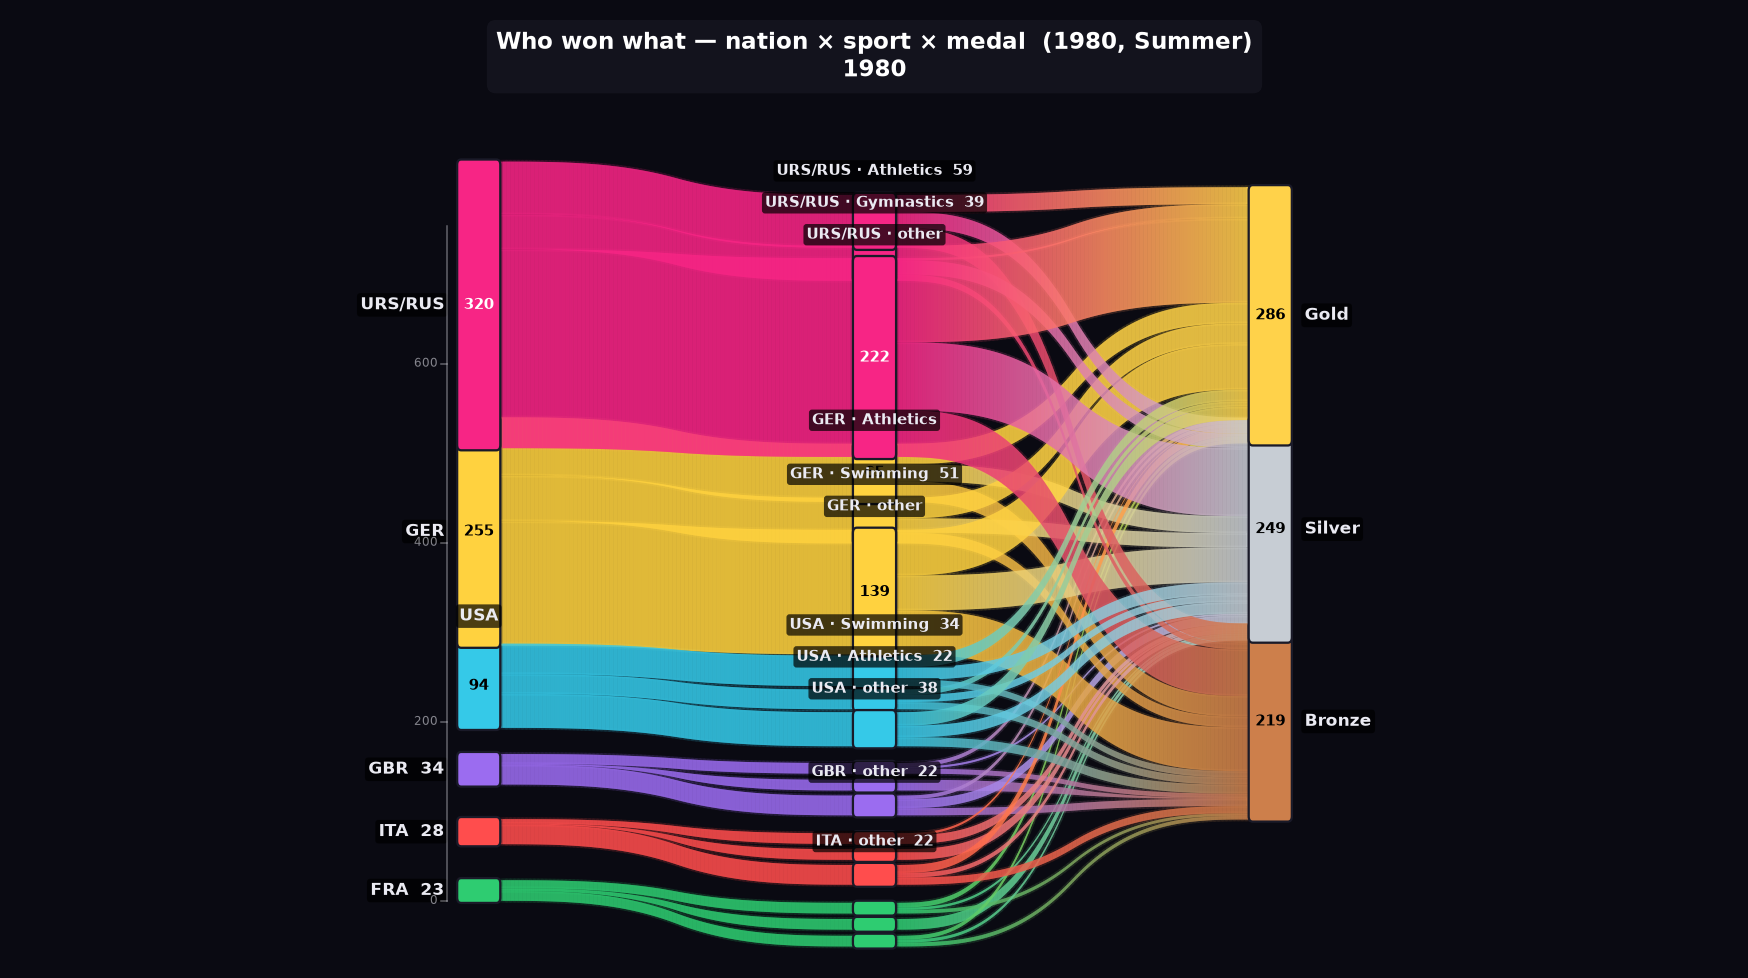

In [9]:
still_design = dict(
    figsize=(16, 9), dpi=110, font_size=11, title_fontsize=15, padding=2.8,
    margin_top=0.14, margin_bottom=0.10,
    ranking_mode=True, stacked_mode=True,            # race + synchronized grouping (reads self.child_parent)
    theme="dark", link_glow=1, link_alpha=0.6, n_segments=90,
    yaxis_node=anchor, yaxis_suffix="", yaxis_gap=0.15,
    layer0_label_side="left", value_prefix="",       # medals, not dollars
)
y2i = {f["time_label"]: i for i, f in enumerate(sk.frames)}
paths = []
for yr in ("1936", "1980"):
    if yr not in y2i:
        continue
    p = os.path.join(ASSETS, f"attribution_{yr}.png")
    sk.save_frame(p, frame_index=y2i[yr],
                  title=f"Who won what — nation × sport × medal  ({yr}, {SEASON})", **still_design)
    paths.append(p); print("saved", p)
for p in paths:
    display(show(p, w=1000))



### One short animation 🎬

A few seconds with the **full** design — synchronized racing, per‑nation colours, the medal‑count
axis, the overlay, and the **beat captions/pauses**. The cell **skips gracefully** without FFmpeg.


In [10]:
sample_mp4 = os.path.join(ASSETS, "attribution_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=24, duration_seconds=10, quality="medium", n_workers=2,
        font_size=11, title_fontsize=17, padding=2.8,
        margin_top=0.16, margin_bottom=0.28,
        ranking_mode=True, stacked_mode=True,                 # race + synchronized grouping
        dynamic_color_mode="static",                          # colour = NATION identity (not rank)
        fixed_color_nodes={"Gold", "Silver", "Bronze"},       # keep medals metallic
        theme="dark", link_glow=1, link_alpha=0.6, n_segments=90,
        yaxis_node=anchor, yaxis_suffix="", yaxis_gap=0.15,
        layer0_label_side="left", value_prefix="",
        title=("A Century at the Top — USA vs USSR and the race for Olympic #1\n"
               f"top {len(top_nocs)} nations re-ranked every Games · signature sports · gold/silver/bronze"),
        overlay_series=[float(df[df.year==y]['value'].sum()) for y in years],
        overlay_x_labels=[str(y) for y in years],
        overlay_label=f"Combined medals of the {len(top_nocs)} leading nations · rolling {ROLL}-Games",
        overlay_color="#FFD24A", overlay_value_suffix="", overlay_badge=f"TOP {len(top_nocs)}",
        overlay_band=(0.16, 0.42),
        annotations={"1956": "The USSR arrives — and takes #1",
                     "1980": "USA boycotts Moscow — USSR 320 to 94",
                     "1984": "Payback — Soviet bloc skips LA",
                     "1992": "Last dance: the USSR, dissolved"},
        hold_periods={"1956": 40, "1980": 60, "1984": 35, "1992": 55},
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 3
  - Nodes per layer: [6, 18, 3]
  - FPS: 24, Duration: 10s
  - Quality: medium
  - Total frames: 240
  - Gradient segments: 90
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Static

Pre-computing 240 frames...
  Pre-computation: 0.02s
  Workers: 2

Rendering on 2 parallel processes...


Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.
Reason: MemoryError((900, 1600, 3), dtype('uint8'))



### Reuse it — wrap it in one function

Everything above is the whole pipeline. To turn it into a one‑liner you can re‑run with different
parameters, wrap the steps in an `attribution_flows(season, n_countries, k_sports, roll, cumulative)`
helper (download → de‑dup keeping `Sport` → stitch → un‑pool the middle → balanced rolling‑window
flows → per‑nation colours) and an `attribution_reel(...)` that calls `from_dataframe` +
`set_group_parents` + `animate`. Then a single call renders the full reel:

```python
# nation -> nation·sport -> medal, Summer, synchronized race + beats
attribution_reel(season="Summer", n_countries=6, k_sports=2, roll=2, duration=55)

# more nations / more sports per nation:
attribution_reel(season="Summer", n_countries=8, k_sports=3, quality="high")

# all-time totals instead of the rolling window; or the Winter Games:
attribution_reel(cumulative=True)
attribution_reel(season="Winter")
```



## 11 · Recap & try it yourself

🎉 **You built the capstone reel** — and learned the deepest idea in the whole tutorial path: a Sankey
**pools at every node**, so to keep a three‑way join you must **un‑pool** the middle and, if you want
motion too, **synchronize** the ranking.

**The pipeline, in one breath:** download `athlete_events.csv` (cached) → **de‑dup keeping `Sport`** +
**stitch** dissolved NOCs (*verified* USA golds ≈ 1,000) → EDA (signature sports + per‑window leaders)
→ **un‑pool** the middle into `"<NOC> · sport"` nodes → balanced **rolling‑window** `country →
nation·sport → medal` flows → per‑nation colours + metallic medals → `from_dataframe` →
**`set_group_parents`** (synchronized ranking) → `save_frame` stills + `animate` with **stacking +
ranking + synchronized grouping + static identity colours + `fixed_color_nodes` + value axis + overlay
+ beat captions**.

### 🧪 Try it yourself

1. **More detail.** Raise `K_SPORTS` to 3 (or `TOP_N` to 8) — more named sports per nation, a busier
   but richer middle column. (Watch label crowding — that's the natural limit.)
2. **All‑time, not rolling.** Replace the `rolling(ROLL)` with a `cumsum` for a monotonic build‑up of
   each nation's medal anatomy (the `--cumulative` mode).
3. **Winter Games.** Set `SEASON = "Winter"` and re‑run — Norway, USSR/Russia, Germany, USA, Canada on
   snow and ice, with *their* signature sports (Cross‑Country, Speed Skating, Biathlon).
4. **Colour = rank instead of identity.** Flip to `dynamic_color_mode="ranking"` and *remove*
   `set_group_parents` to feel *why* identity‑colour + grouping is the right call here — the chart
   becomes a pretty race you can no longer *read*.
5. **A different framing.** Swap the overlay to the **leader's margin** (`#1 − #2` medals) for a footer
   that spikes at 1980 — the line and the Sankey then tell the same story.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- The simpler sibling (the ranking race of nations): `notebooks/08_tutorial_olympics.ipynb`
- The dataset — *120 years of Olympic history* (free, no API key):
  https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results

> 💡 **The one idea to remember:** a Sankey's intermediate nodes **pool** their inflows, so a shared
> `sport` node loses *whose* medal it is. **Un‑pool** it into nation‑specific nodes to keep the join,
> and use **`set_group_parents`** to let the nations *race* while their sports stay grouped. Colour by
> **identity** (static), not rank, when the colour *is* the label. 💙

*Built com todo cuidado e carinho. Data: 120 years of Olympic history (free, no API key). Happy hacking!*
